In [ ]:
import numpy as np
import matplotlib.pyplot as plt


LLN in 2D (average displacement)
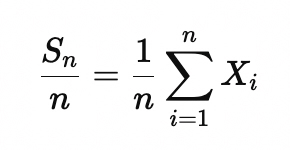

In [ ]:
def random_walk_1d(n_steps=5000, p=0.5):
    """
    p = probability of step +1
    """
    steps = np.where(np.random.rand(n_steps) < p, 1, -1)
    position = np.cumsum(steps)
    return steps, position


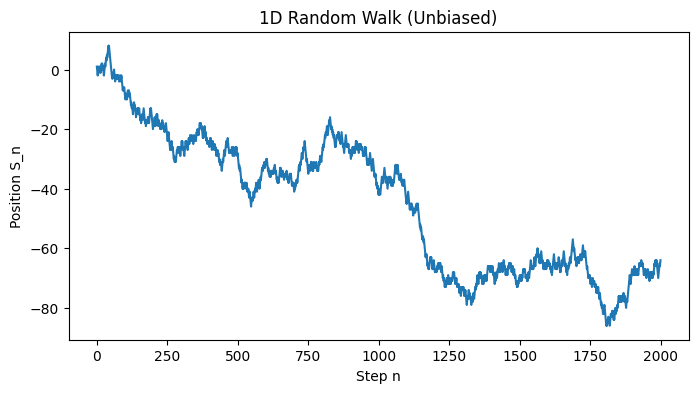

In [ ]:
steps, position = random_walk_1d(n_steps=2000, p=0.5)

plt.figure(figsize=(8,4))
plt.plot(position)
plt.xlabel("Step n")
plt.ylabel("Position S_n")
plt.title("1D Random Walk (Unbiased)")
plt.show()


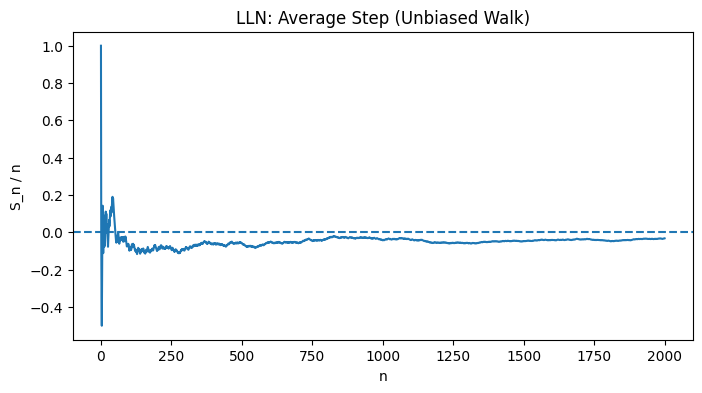

In [ ]:
n = len(steps)
average_position = position / np.arange(1, n + 1)

plt.figure(figsize=(8,4))
plt.plot(average_position)
plt.axhline(0, linestyle="--")
plt.xlabel("n")
plt.ylabel("S_n / n")
plt.title("LLN: Average Step (Unbiased Walk)")
plt.show()


In [ ]:
def llm_trials(n_trials=200, n_steps=3000, p=0.5):
    averages = []

    for _ in range(n_trials):
        _, position = random_walk_1d(n_steps, p)
        avg = position / np.arange(1, n_steps + 1)
        averages.append(avg)

    return np.array(averages)


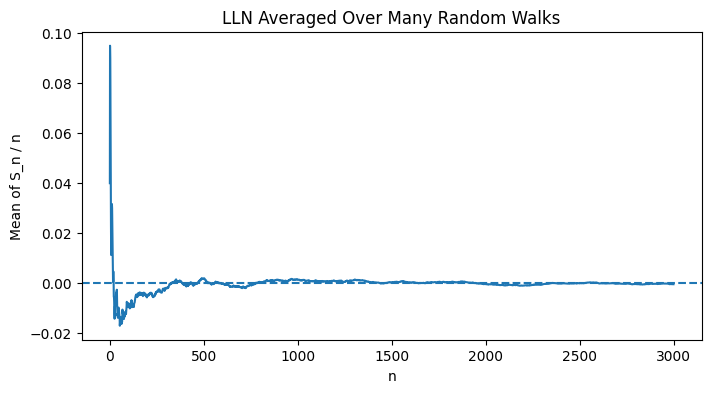

In [ ]:
averages = llm_trials(p=0.5)

plt.figure(figsize=(8,4))
plt.plot(averages.mean(axis=0))
plt.axhline(0, linestyle="--")
plt.xlabel("n")
plt.ylabel("Mean of S_n / n")
plt.title("LLN Averaged Over Many Random Walks")
plt.show()


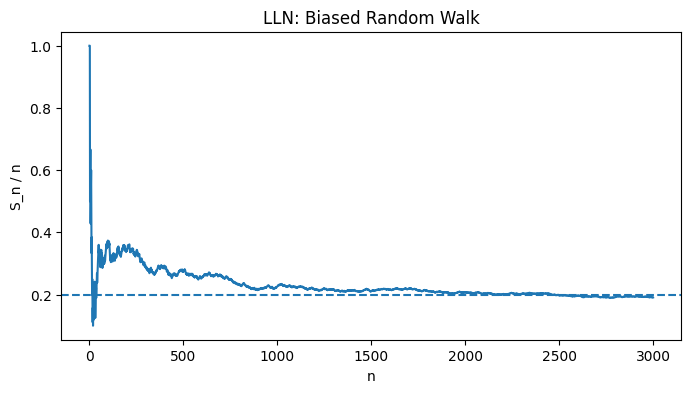

In [ ]:
p = 0.6  # bias
steps, position = random_walk_1d(n_steps=3000, p=p)

average_position = position / np.arange(1, len(position) + 1)

plt.figure(figsize=(8,4))
plt.plot(average_position)
plt.axhline(2*p - 1, linestyle="--")
plt.xlabel("n")
plt.ylabel("S_n / n")
plt.title("LLN: Biased Random Walk")
plt.show()


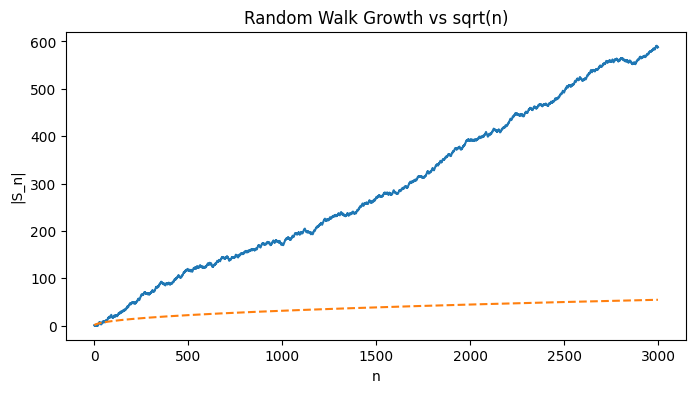

In [ ]:
plt.figure(figsize=(8,4))
plt.plot(np.abs(position))
plt.plot(np.sqrt(np.arange(1, len(position) + 1)), linestyle="--")
plt.xlabel("n")
plt.ylabel("|S_n|")
plt.title("Random Walk Growth vs sqrt(n)")
plt.show()


2D Random Walk Definition

In [ ]:
def random_walk_2d(n_steps=1000):
    steps = np.zeros((n_steps, 2))

    directions = np.array([
        [1, 0],   # right
        [-1, 0],  # left
        [0, 1],   # up
        [0, -1]   # down
    ])

    choices = np.random.choice(4, size=n_steps)
    steps = directions[choices]

    position = np.cumsum(steps, axis=0)
    return steps, position


Plot the 2D path (classic visualization)
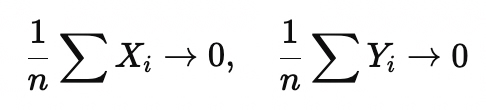

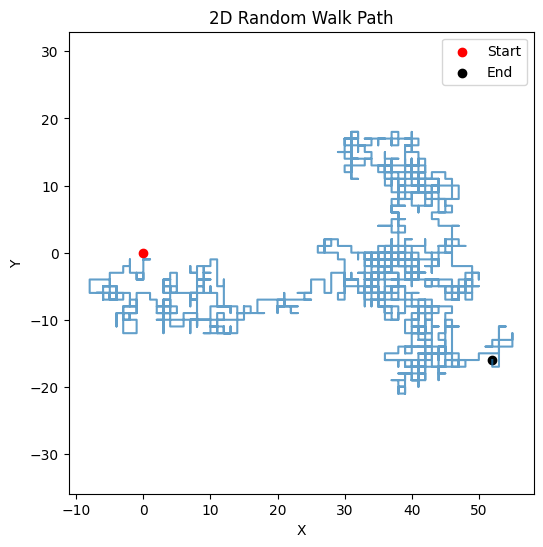

In [ ]:
steps, position = random_walk_2d(n_steps=2000)

plt.figure(figsize=(6,6))
plt.plot(position[:,0], position[:,1], alpha=0.7)
plt.scatter(0, 0, c='red', label="Start")
plt.scatter(position[-1,0], position[-1,1], c='black', label="End")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("2D Random Walk Path")
plt.legend()
plt.axis("equal")
plt.show()


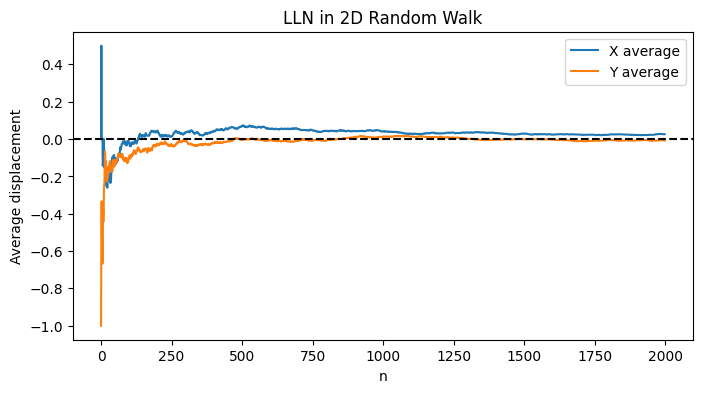

In [ ]:
n = len(position)
avg_position = position / np.arange(1, n+1).reshape(-1,1)

plt.figure(figsize=(8,4))
plt.plot(avg_position[:,0], label="X average")
plt.plot(avg_position[:,1], label="Y average")
plt.axhline(0, linestyle="--", color="black")
plt.xlabel("n")
plt.ylabel("Average displacement")
plt.title("LLN in 2D Random Walk")
plt.legend()
plt.show()


In [ ]:
def biased_random_walk_2d(n_steps=2000, bias=(0.1, 0)):
    steps = np.random.choice([-1, 1], size=(n_steps, 2))
    steps = steps + np.array(bias)
    position = np.cumsum(steps, axis=0)
    return steps, position
